# Chapter 51: Time Series Cross-Validation

**How much does a backtest that ignores label availability flatter each recipe, and does it still rank the recipes correctly?**

The chapter's rule is to exclude training rows whose labels would arrive after the validation origin, and its six-row example excludes row D for exactly that reason. Measuring the flattery as the delay grows shows who benefits from the shortcut and whether a recipe choice made with it would survive.

*Constructed data and models; the sizes of these effects depend on the drift speed chosen here, not on a competition result.*

## The experiment

Constructed daily data: ten rows a day, five features, and a target that is linear in them with coefficients that drift slowly (about 25 days of memory) plus unit noise. Two ridge regression recipes are backtested at five forecast origins, each scored on the next 30 days: one trains on only the last 30 usable days, one on all usable history. A row's label is available delay days after it is observed. The honest backtest trains on rows with observation day plus delay before the origin, as the chapter's splitter does; the naive one trains on every row observed before the origin. A control world with fixed coefficients checks the leak without drift. Everything is a mean over 160 series.

In [1]:
import numpy as np
from sklearn.linear_model import Ridge

from kaggle_companion.activities._common import clean

SEED = 51
DRAWS = 160                      # independent series; every estimate is a mean over draws (40 was too few to rank the recipes)
DAYS, ROWS, FEATURES = 420, 10, 5
BLOCK = 30                       # each assessment block covers the 30 days after its forecast origin
ORIGINS = [100, 130, 160, 190, 220]
DRIFT = 0.04                     # daily pull of the coefficients toward a fresh random draw (about 25 days of memory)
SHORT_WINDOW = 30                # the "recent history only" recipe trains on the last 30 usable days


def generate(rng, drift):
    """Ten rows a day. The target is linear in five features whose coefficients drift slowly (a stationary process), plus noise of sd 1."""
    beta = np.zeros((DAYS, FEATURES))
    beta[0] = rng.normal(size=FEATURES)
    for t in range(1, DAYS):
        beta[t] = (1 - drift) * beta[t - 1] + np.sqrt(1 - (1 - drift) ** 2) * rng.normal(size=FEATURES)
    X = rng.normal(size=(DAYS, ROWS, FEATURES))
    return X, (beta[:, None, :] * X).sum(2) + rng.normal(size=(DAYS, ROWS))


def backtest_mae(X, y, delay, window, respect_availability):
    """Mean absolute error over the assessment blocks. A row observed on day d has its label available on day d + delay.
    Honest rule: train on rows with d + delay < origin. Naive rule: train on every row observed before the origin,
    including rows whose labels would still be on the way. `window` keeps only the most recent usable days (None keeps all)."""
    errors = []
    for origin in ORIGINS:
        last = origin - delay if respect_availability else origin
        first = 0 if window is None else max(0, last - window)
        model = Ridge(alpha=1.0).fit(X[first:last].reshape(-1, FEATURES), y[first:last].reshape(-1))
        block = slice(origin, origin + BLOCK)
        errors.append(np.mean(np.abs(model.predict(X[block].reshape(-1, FEATURES)) - y[block].reshape(-1))))
    return float(np.mean(errors))


def run(delay):
    rng = np.random.default_rng(SEED)
    recipes = {"short": SHORT_WINDOW, "expanding": None}
    rows = {f"{rule}_{name}": [] for rule in ("naive", "honest") for name in recipes}
    stable = []
    for _ in range(DRAWS):
        X, y = generate(rng, DRIFT)
        for name, window in recipes.items():
            for rule in ("naive", "honest"):
                rows[f"{rule}_{name}"].append(backtest_mae(X, y, delay, window, rule == "honest"))
        X, y = generate(rng, 0.0)                              # control world: coefficients never change
        stable.append(backtest_mae(X, y, delay, None, True) - backtest_mae(X, y, delay, None, False))
    mean = {k: float(np.mean(v)) for k, v in rows.items()}
    # Optimism of the naive backtest: how much lower its error is than the honest one, per recipe (paired by series).
    optimism = {name: np.array(rows[f"honest_{name}"]) - np.array(rows[f"naive_{name}"]) for name in recipes}
    # Difference between recipes under each rule; negative means the short-window recipe has the lower error.
    naive_diff = np.array(rows["naive_short"]) - np.array(rows["naive_expanding"])
    honest_diff = np.array(rows["honest_short"]) - np.array(rows["honest_expanding"])
    se = lambda a: np.std(a, ddof=1) / np.sqrt(DRAWS)
    return clean({
        "delay": delay, **mean,
        **{f"optimism_{name}": optimism[name].mean() for name in recipes},
        **{f"optimism_{name}_se": se(optimism[name]) for name in recipes},
        "naive_diff": naive_diff.mean(), "naive_diff_se": se(naive_diff),
        "honest_diff": honest_diff.mean(), "honest_diff_se": se(honest_diff),
        "stable_gap": np.mean(stable), "stable_gap_se": se(stable),
        "draws": DRAWS, "origins": len(ORIGINS), "noise_floor": 0.7979,
    })


## Measure it across the control

The control is **label delay (days between observing a row and receiving its label)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch51 import explain

VALUES = [0, 10, 30, 60]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                0      10      30      60
Naive MAE, 30-day window    1.919   1.919   1.919   1.919
Honest MAE, 30-day window   1.919   2.081   2.241   2.316
Naive MAE, expanding        1.957   1.957   1.957   1.957
Honest MAE, expanding       1.957   2.008   2.080   2.164
Optimism, 30-day window    +0.000  +0.162  +0.322  +0.397
Optimism, expanding        +0.000  +0.051  +0.123  +0.207


## Look at it

The figure shows the default setting, label delay (days between observing a row and receiving its label) = 30.

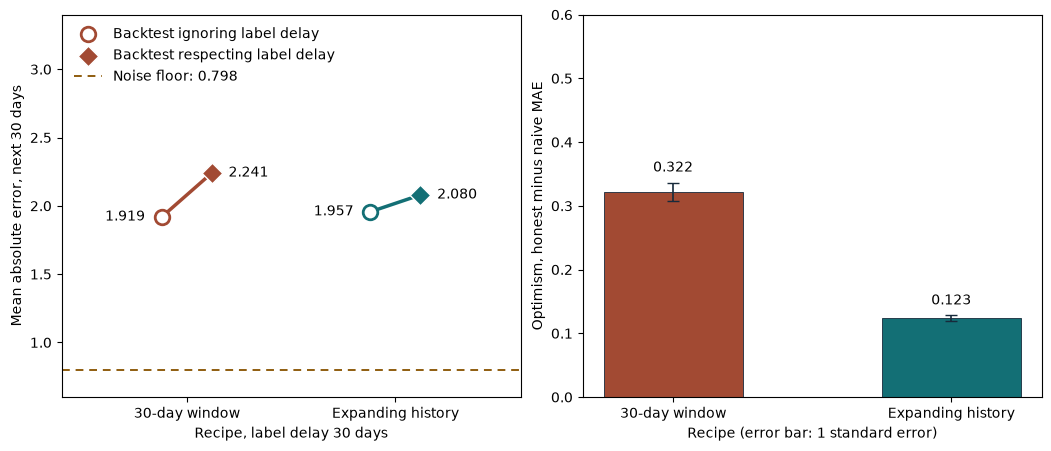

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch51 import draw, NCOLS, HEIGHT

DEFAULT = 30
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With a 30-day delay the naive backtest scores the 30-day window 1.919 and the expanding recipe 1.957, a gap of -0.038 (standard error 0.013), so it prefers the 30-day window; the honest backtest reverses that, with the expanding recipe ahead by 0.161 (standard error 0.015). Respecting availability raises the short window's error to 2.241: 2.241 - 1.919 = 0.322 of optimism, against 0.123 for the expanding recipe. With fixed coefficients the two rules differ by 0.001 MAE, so the effect comes from a relationship that changes.

- Short window optimism: 2.241 - 1.919 = +0.322 (standard error 0.015).
- Expanding optimism: 2.080 - 1.957 = +0.123 (standard error 0.005).
- Naive ranking gap, short minus expanding: 1.919 - 1.957 = -0.038.
- Honest ranking gap, short minus expanding: 2.241 - 2.080 = +0.161.

## Apply this to your competition

- Store the date each label becomes available next to the observation date, and build every training set from labels known by the origin.
- Use the chapter's forward_date_splits (or the same rule) with label-availability dates, and verify it on a six-row example first.
- Do not choose between a recent-window recipe and a long-history recipe with a backtest that ignores label delay.
- Report the delay you assumed and re-run the comparison if the delay changes in production.

Book location: Chapter 51, Define the Forecast Origin.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)